Homework 5, problem 3, part b

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import solve

In [2]:
p = np.array([
    [0,   1/2, 1/2, 0,   0,   0,   0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0,   0],
    [1/2, 0,   0,   0,   1/2, 0,   0,   0],
    [1/3, 0,   1/3, 0,   1/3, 0,   0,   0],
    [0,   1/3, 0,   0,   0,   1/3, 1/3, 0],
    [0,   0,   0,   0,   0,   1,   0,   0],
    [0,   0,   0,   0,   0,   0,   0,   1],
    [0,   0,   0,   0,   0,   0,   1,   0]
], dtype=float)

n = 8
d = 0.85
G = d * p + (1 - d) / n * np.ones((n, n))

In [3]:
# power iteration
n = 8
q = np.ones(n) / n # uniform distribution 
tol = 1e-10 
iteration = 0 

while True: 
    q_new = q @ G 
    diff = np.sum(np.abs(q_new - q)) 
    iteration += 1 
    
    if diff < tol: 
        break 
    
    q = q_new 
    
pi = q_new 

print("number of iterations:", iteration) 
print("final L1 difference:", diff) 
print("stationary distribution pi:") 
for i in range(n): 
    print(f"page {i+1}: {pi[i]:.12f}") 
print("sum of pi:", np.sum(pi))

number of iterations: 124
final L1 difference: 9.566987480003064e-11
stationary distribution pi:
page 1: 0.071756653940
page 2: 0.069577629874
page 3: 0.092507876885
page 4: 0.048320492697
page 5: 0.071756653940
page 6: 0.260540346332
page 7: 0.198265052049
page 8: 0.187275294282
sum of pi: 1.0000000000000018


In [4]:
# linear solve
A = G.T - np.eye(n) 
b = np.zeros(n) 
# Replace last equation with normalization condition 
A[-1, :] = 1 
b[-1] = 1 
pi_solve = solve(A, b) 
print("stationary distribution from linear solve:") 
for i in range(n): 
    print(f"Page {i+1}: {pi_solve[i]:.12f}") 
    
print("difference between methods:", np.max(np.abs(pi - pi_solve)))

stationary distribution from linear solve:
Page 1: 0.071756653940
Page 2: 0.069577629874
Page 3: 0.092507876885
Page 4: 0.048320492697
Page 5: 0.071756653940
Page 6: 0.260540346332
Page 7: 0.198265052071
Page 8: 0.187275294260
difference between methods: 2.1978391329113833e-11


In [5]:
# page ranking
ranking = np.argsort(-pi) 
for rank, page in enumerate(ranking, start=1): 
    print(f"Rank {rank}: Page {page + 1} " 
          f"(PageRank = {pi[page]:.12f})" )

Rank 1: Page 6 (PageRank = 0.260540346332)
Rank 2: Page 7 (PageRank = 0.198265052049)
Rank 3: Page 8 (PageRank = 0.187275294282)
Rank 4: Page 3 (PageRank = 0.092507876885)
Rank 5: Page 1 (PageRank = 0.071756653940)
Rank 6: Page 5 (PageRank = 0.071756653940)
Rank 7: Page 2 (PageRank = 0.069577629874)
Rank 8: Page 4 (PageRank = 0.048320492697)


In [6]:
# why pages 1 and 5 tie
print("Page 1:", pi[0]) 
print("Page 5:", pi[4]) 
print("Difference:", pi[0] - pi[4])

Page 1: 0.07175665394027061
Page 5: 0.07175665394027061
Difference: 0.0


Part c

In [7]:
np.random.seed(12345)

R = 100
T = 10**5
current = np.zeros(R, dtype = int)
counts = np.zeros((R, n), dtype = int)

In [8]:
# discrete inverse transform

for t in range(T):

    u = np.random.rand(R) # random variable
    probs = G[current, :] # transition probabilities
    cdf = np.cumsum(probs, axis=1) # cumulative probabilities

    # discrete inverse transform
    next_state = np.argmax(u[:, None] <= cdf, axis=1)
    current = next_state
    counts[np.arange(R), current] += 1

pi_hat = counts / T
print("true pi:", pi)
print("Time estimate for surfer 1:", pi_hat[0])

true pi: [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
Time estimate for surfer 1: [0.06993 0.06842 0.09177 0.0482  0.0722  0.26684 0.19673 0.18591]


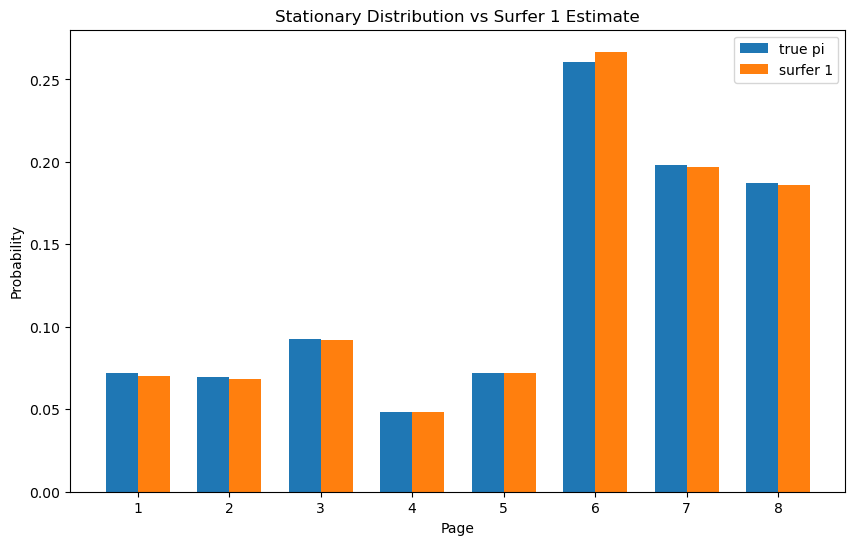

In [9]:
pages = np.arange(1, 9)
width = 0.35

plt.figure(figsize = (10, 6))

plt.bar(pages - width/2, pi, width, label = "true pi")
plt.bar(pages + width/2, pi_hat[0], width, label = "surfer 1")

plt.xlabel("Page")
plt.ylabel("Probability")
plt.title("Stationary Distribution vs Surfer 1 Estimate")

plt.xticks(pages)
plt.legend()
plt.show()

In [10]:
# T values from 10^2 to 10^5
T_values = np.unique(np.round(np.logspace(2, 5, 100)).astype(int))

np.random.seed(12345)
current = np.zeros(R, dtype = int)
counts = np.zeros((R, n), dtype=int)
rms_errors = []
T_index = 0

# simulation
for t in range(1, T + 1):

    u = np.random.rand(R)
    probs = G[current, :]
    cdf = np.cumsum(probs, axis=1)
    next_state = np.argmax(u[:, None] <= cdf,axis=1)
    current = next_state
    counts[np.arange(R), current] += 1

    if T_index < len(T_values) and t == T_values[T_index]:
        
        estimates = counts / t
        errors = np.abs(estimates - pi[None, :])
        max_errors = np.max(errors, axis=1)

        # RMS over the 100 surfers
        rms = np.sqrt(np.mean(max_errors ** 2))
        rms_errors.append(rms)
        T_index += 1

rms_errors = np.array(rms_errors)

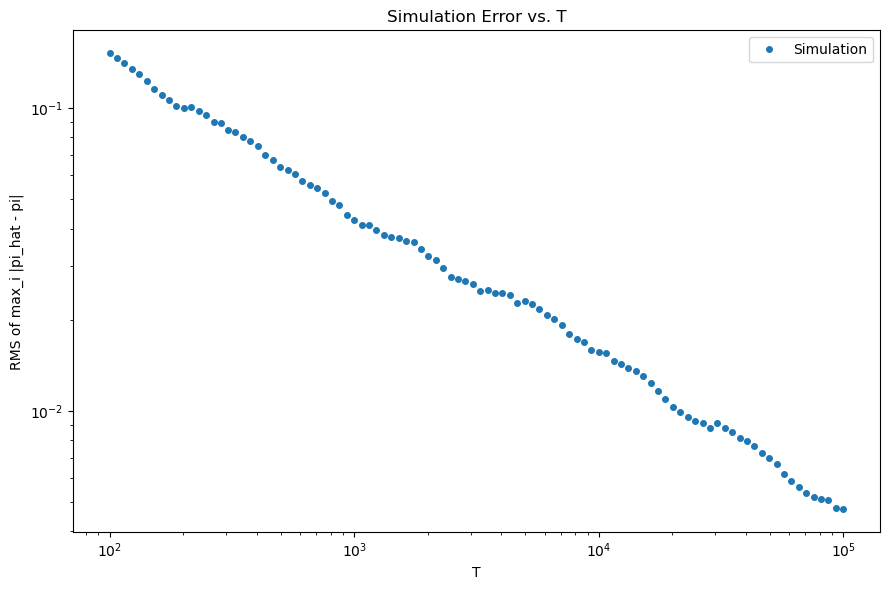

In [11]:
plt.figure(figsize=(9, 6))

plt.loglog(
    T_values,
    rms_errors,
    'o',
    markersize=4,
    label = "Simulation"
)

plt.xlabel("T")
plt.ylabel("RMS of max_i |pi_hat - pi|")
plt.title("Simulation Error vs. T")
plt.legend()

plt.tight_layout()
plt.show()


log_T = np.log(T_values)
log_error = np.log(rms_errors)

slope, intercept = np.polyfit(
    log_T,
    log_error,
    1
)

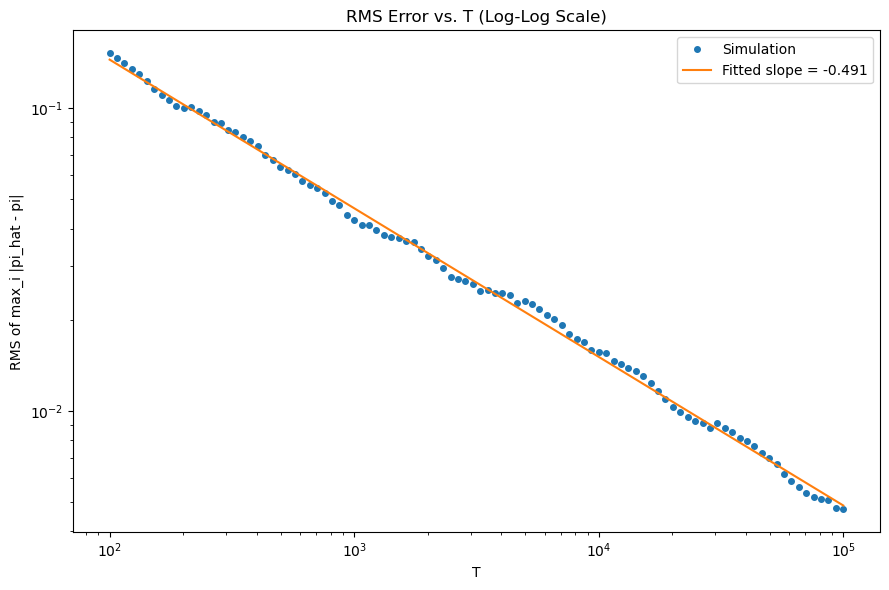

In [12]:
fitted_error = np.exp(
    intercept + slope * log_T
)

plt.figure(figsize=(9, 6))

plt.loglog(
    T_values,
    rms_errors,
    'o',
    markersize=4,
    label="Simulation"
)

plt.loglog(
    T_values,
    fitted_error,
    '-',
    label=f"Fitted slope = {slope:.3f}"
)

plt.xlabel("T")
plt.ylabel("RMS of max_i |pi_hat - pi|")
plt.title("RMS Error vs. T (Log-Log Scale)")

plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# comparing T = 10^5 error with sqrt(pi_6(1-pi_6)/T)

T_final = 10**5
pi6 = pi[5]

independent_se = np.sqrt(
    pi6 * (1 - pi6) / T_final
)

observed_error = rms_errors[-1]

print(
    "sqrt(pi_6(1-pi_6)/T):",
    independent_se
)

print(
    "Observed RMS max error:",
    observed_error
)

print(
    "Ratio:",
    observed_error / independent_se
)

final_estimates = counts / T_final

page6_errors = final_estimates[:, 5] - pi6

page6_rms = np.sqrt(
    np.mean(page6_errors**2)
)

print("\nPage 6 RMS error:", page6_rms)

print(
    "Page 6 RMS / independent SE:",
    page6_rms / independent_se
)

sqrt(pi_6(1-pi_6)/T): 0.0013880168380283457
Observed RMS max error: 0.004723128098505178
Ratio: 3.402788762429065

Page 6 RMS error: 0.004374200923802477
Page 6 RMS / independent SE: 3.1514033576249374
